In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

from tensorflow.keras.datasets import mnist

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [6]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

print(f"Data type: {X_train.dtype}")

print(f"Classes: {np.unique(y_train)}")

unique, counts = np.unique(y_train, return_counts=True)
print("\nClass distribution (Train):")
for u, c in zip(unique, counts):
    print(f"Digit {u}: {c} samples")

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)
Data type: uint8
Classes: [0 1 2 3 4 5 6 7 8 9]

Class distribution (Train):
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples


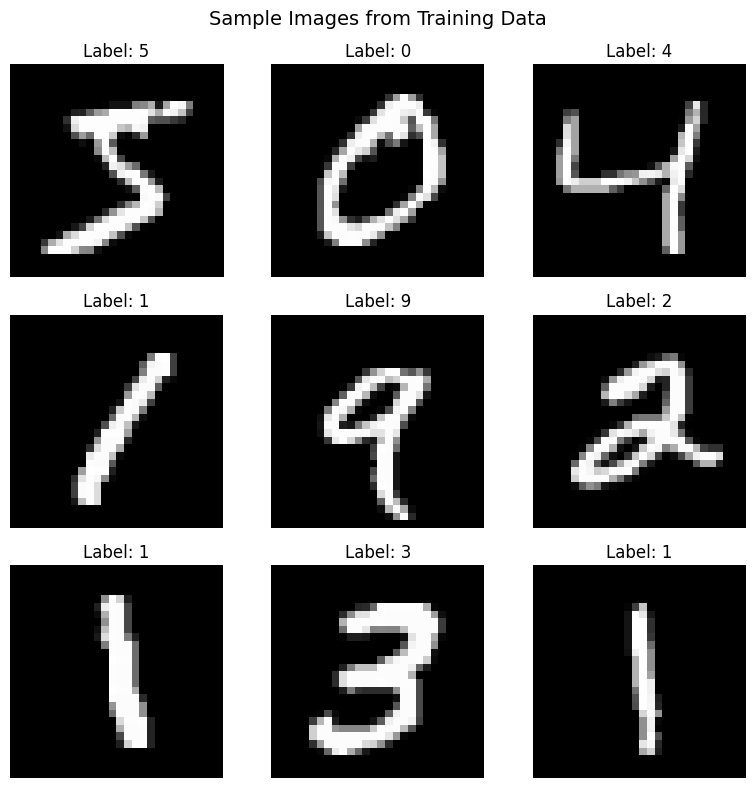

In [7]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.suptitle("Sample Images from Training Data", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = np.expand_dims(X_train, axis=-1)
X_test  = np.expand_dims(X_test, axis=-1)

print(f"New Train shape: {X_train.shape}")
print(f"New Test shape: {X_test.shape}")

New Train shape: (60000, 28, 28, 1)
New Test shape: (10000, 28, 28, 1)


In [9]:
model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 2
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 3 
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Fully Connected
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output
model.add(Dense(10, activation='softmax'))

# Summary
model.summary()

C:\anacondanew\envs\cnn_project\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 7, 7, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 242,954 (949.04 KB)

 Trainable params: 242,250 (946.29 KB)

 Non-trainable params: 704 (2.75 KB)

In [10]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-5
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 167s 165ms/step - accuracy: 0.9630 - loss: 0.1254 - val_accuracy: 0.9877 - val_loss: 0.0382 - learning_rate: 0.0010
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 193s 155ms/step - accuracy: 0.9856 - loss: 0.0483 - val_accuracy: 0.9892 - val_loss: 0.0340 - learning_rate: 0.0010
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 135s 144ms/step - accuracy: 0.9894 - loss: 0.0361 - val_accuracy: 0.9897 - val_loss: 0.0319 - learning_rate: 0.0010
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 139s 141ms/step - accuracy: 0.9911 - loss: 0.0294 - val_accuracy: 0.9865 - val_loss: 0.0466 - learning_rate: 0.0010
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 144s 143ms/step - accuracy: 0.9929 - loss: 0.0219 - val_accuracy: 0.9910 - val_loss: 0.0281 - learning_rate: 0.0010
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 134s 143ms/step - accuracy: 0.9938 - loss: 0.0204 - val_accuracy: 0.9886 - val_loss: 0.0366 - learning_rate: 0.0010
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 134s 143ms/step - accura

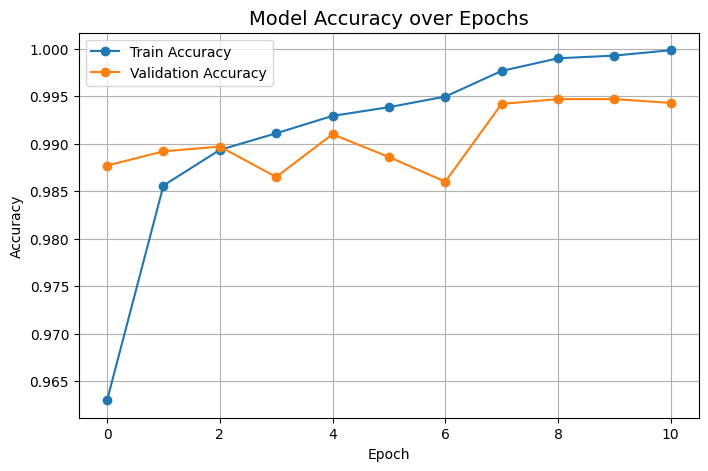

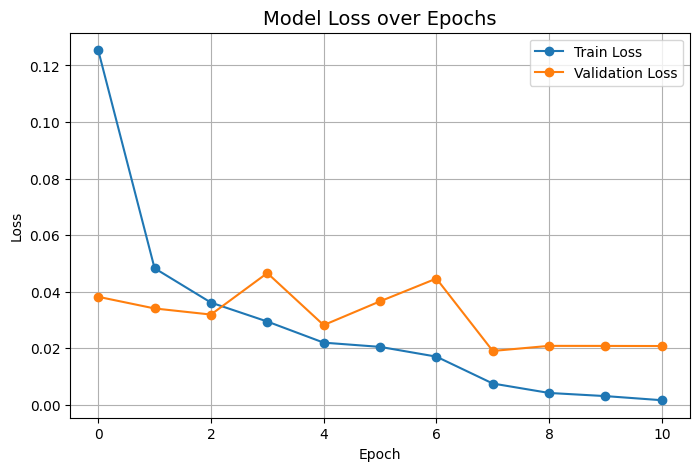

In [12]:
# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')

plt.title("Model Accuracy over Epochs", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.grid(True)

plt.show()


# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')

plt.title("Model Loss over Epochs", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train Loss', 'Validation Loss'])
plt.grid(True)

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step
=== Final Results ===
Test Accuracy: 0.9942
Test Loss: 0.0190

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      1.00      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



Text(58.222222222222214, 0.5, 'Actual')

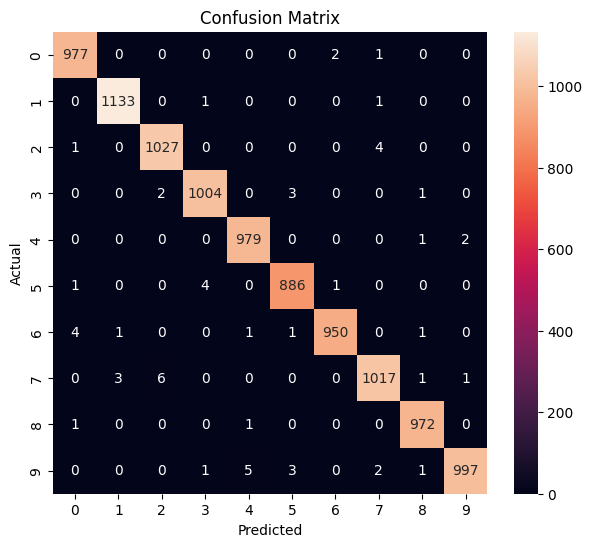

In [13]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("=== Final Results ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [15]:
# Predict first 5 samples
pred = model.predict(X_test[:5])

pred_classes = np.argmax(pred, axis=1)

print("Predicted:", pred_classes)
print("Actual:   ", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
Predicted: [7 2 1 0 4]
Actual:    [7 2 1 0 4]


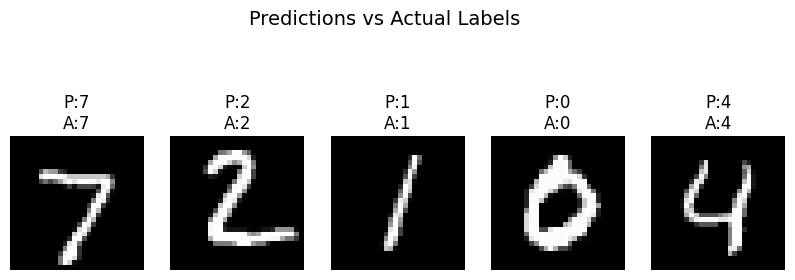

In [16]:
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.title(f"P:{pred_classes[i]}\nA:{y_test[i]}")

plt.suptitle("Predictions vs Actual Labels", fontsize=14)
plt.show()